## ***Import Required Libraries***

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer


from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

## ***Load the Dataset***

In [2]:
file_path = (r"C:\Users\saket\Downloads\Processed_Flipdata (1).xlsx") # update path if needed
df = pd.read_excel(file_path)

df.head()

,Unnamed: 0,Model,Colour,Memory,RAM,Battery_,Rear Camera,Front Camera,AI Lens,Mobile Height,Processor_,Prize
0,0,Infinix SMART 7,Night Black,64,4,6000,13MP,5MP,1,16.76,Unisoc Spreadtrum SC9863A1,7299
1,1,Infinix SMART 7,Azure Blue,64,4,6000,13MP,5MP,1,16.76,Unisoc Spreadtrum SC9863A1,7299
2,2,MOTOROLA G32,Mineral Gray,128,8,5000,50MP,16MP,0,16.64,Qualcomm Snapdragon 680,11999
3,3,POCO C50,Royal Blue,32,2,5000,8MP,5MP,0,16.56,Mediatek Helio A22,5649
4,4,Infinix HOT 30i,Marigold,128,8,5000,50MP,5MP,1,16.76,G37,8999


## ***Basic Structure of the Dataset***

In [3]:
df.rename(columns={"Prize": "Price"}, inplace=True)
df.shape
df.columns
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541 entries, 0 to 540
Data columns (total 12 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Unnamed: 0     541 non-null    int64  
 1   Model          541 non-null    object 
 2   Colour         541 non-null    object 
 3   Memory         541 non-null    int64  
 4   RAM            541 non-null    int64  
 5   Battery_       541 non-null    int64  
 6   Rear Camera    541 non-null    object 
 7   Front Camera   541 non-null    object 
 8   AI Lens        541 non-null    int64  
 9   Mobile Height  541 non-null    float64
 10  Processor_     541 non-null    object 
 11  Price          541 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 50.8+ KB


***This shows the basic information of the dataset including number of entries, column names, non-null counts (missing values check), data types of each column, and memory usage.***

## ***Statistical Summary (Numeric Features)***

In [4]:
df.describe()

,Unnamed: 0,Memory,RAM,Battery_,AI Lens,Mobile Height,Price
count,541.000000,541.000000,541.000000,541.000000,541.000000,541.000000,541.000000
mean,289.711645,110.550832,5.397412,4871.587800,0.062847,16.431201,16228.375231
std,182.359185,60.600694,1.984923,780.148862,0.242911,2.523553,10793.588322
min,0.000000,16.000000,2.000000,800.000000,0.000000,4.500000,920.000000
25%,135.000000,64.000000,4.000000,5000.000000,0.000000,16.510000,9290.000000
50%,273.000000,128.000000,6.000000,5000.000000,0.000000,16.710000,13499.000000
75%,434.000000,128.000000,8.000000,5000.000000,0.000000,16.940000,19280.000000
max,642.000000,256.000000,8.000000,7000.000000,1.000000,41.940000,80999.000000


***It Shows:
Mean,
Standard deviation,
Min / Max,
Quartiles,
Count***

## ***Summary for Categorical Columns***

In [5]:
df.describe(include='object')

,Model,Colour,Rear Camera,Front Camera,Processor_
count,541,541,541,541,541
unique,187,275,14,13,123
top,realme C55,Yellow,50MP,16MP,Qualcomm Snapdragon 680
freq,9,12,260,164,33


***It Shows:
Unique values,
Most frequent value and
Frequency of top value***

## ***Missing Values***

In [6]:
df.isnull().sum()

Unnamed: 0       0
Model            0
Colour           0
Memory           0
RAM              0
Battery_         0
Rear Camera      0
Front Camera     0
AI Lens          0
Mobile Height    0
Processor_       0
Price            0
dtype: int64

***The dataset does not contain any missing values in any column.***

## ***Value Range of Each Feature***

### ***Unique Values***

In [7]:
numeric_cols = df.select_dtypes(include=np.number).columns

for col in numeric_cols:
    print(f"{col}: Min = {df[col].min()}, Max = {df[col].max()}")

Unnamed: 0: Min = 0, Max = 642
Memory: Min = 16, Max = 256
RAM: Min = 2, Max = 8
Battery_: Min = 800, Max = 7000
AI Lens: Min = 0, Max = 1
Mobile Height: Min = 4.5, Max = 41.94
Price: Min = 920, Max = 80999


***=> Minimum and maximum values were checked for all numeric columns to understand their ranges and detect possible anomalies.***  
***=> Memory: 16–256 GB (low to high storage phones)***  
***=> RAM: 2–8 GB (budget to higher range devices)***  
***=> Battery: 800–7000 mAh (small to large capacity)***    
***=> Mobile height ranges from 4.5 to 41.94, showing variation in device sizes.***  
***=> Price: 920–80,999 (budget to premium phones)***   

### ***Categorical Columns — Unique Values***

In [8]:
categorical_cols = df.select_dtypes(include='object').columns

for col in categorical_cols:
    print(f"\n{col}:")
    print(df[col].value_counts().head())


Model:
Model
realme C55               9
vivo Y16                 9
REDMI Note 12 Pro 5G     9
SAMSUNG Galaxy A14 5G    9
SAMSUNG Galaxy F14 5G    8
Name: count, dtype: int64

Colour:
Colour
Yellow            12
Black              8
Power Black        8
Royal Blue         8
Midnight Black     7
Name: count, dtype: int64

Rear Camera:
Rear Camera
50MP     260
13MP      63
64MP      62
8MP       52
108MP     31
Name: count, dtype: int64

Front Camera:
Front Camera
16MP    164
5MP     135
8MP     129
13MP     49
32MP     22
Name: count, dtype: int64

Processor_:
Processor_
Qualcomm Snapdragon 680       33
Unisoc T612                   21
Mediatek Helio A22            19
Mediatek Dimensity 1080       18
Qualcomm Snapdragon 695 5G    17
Name: count, dtype: int64


***=> The dataset contains categorical features such as Model, Colour, Camera, and Processor.***  
***=> Some values appear more frequently than others***  
***=> Rear Camera 50MP and Front Camera 16MP are the most common***  
***=> Popular colors include Yellow, Black, and Blue variants***  
***=> Multiple processor types are used, with Snapdragon 680 appearing most often***  
***=> Different phone models are represented in the dataset***  

## ***Check Duplicate Rows***

In [9]:
df.duplicated().sum()
print(df.duplicated().sum())

# Remove all Unnamed columns from BOTH dataframes

df = df.loc[:, ~df.columns.str.contains("^Unnamed")]

if 'df_encoded' in globals():
    df_encoded = df_encoded.loc[:, ~df_encoded.columns.str.contains("^Unnamed")]

0


***=> The dataset contains no duplicate rows***  
***=> Each record represents a unique mobile phone entry***   
***=> Remove all Unnamed columns from BOTH dataframes***  

## Handle Outliers (IQR Method)

In [10]:
# Numeric → fill with median
num_cols = df.select_dtypes(include=np.number).columns

In [11]:
num_cols = df.select_dtypes(include=np.number).columns.drop("Battery_")
for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df[col] = df[col].clip(lower, upper)

***=> Outliers in all numerical features were handled using the IQR method***  
***=> Extreme values were capped within the lower and upper limits***  
***=> No rows were removed; data integrity was preserved***  
***=> This reduces the influence of extreme values on the model***  

## ***Feature Distribution Analysis Using Boxplots***

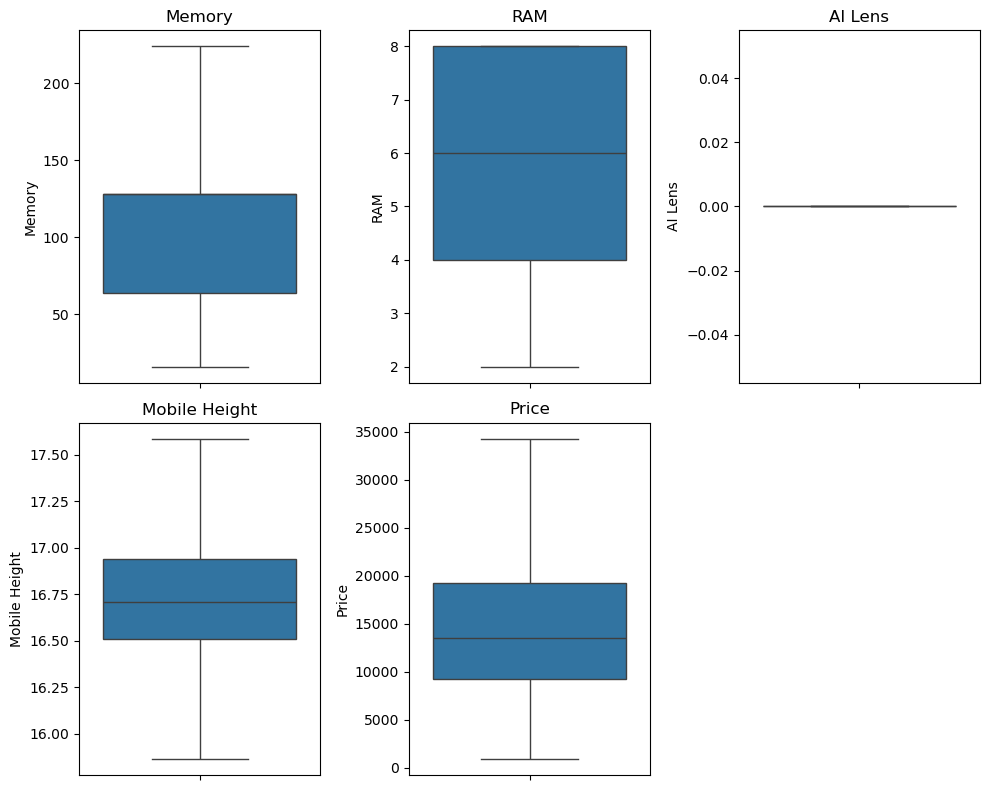

In [12]:
plt.figure(figsize=(10,8))

for i, col in enumerate(num_cols):
    plt.subplot(2,3,i+1)
    sns.boxplot(y=df[col])
    plt.title(col)

plt.tight_layout()
plt.show()

***=> Boxplots were used to visualize the distribution of numerical features and identify potential outliers.***  
***=> The Memory feature shows a wide range of storage capacities, indicating different storage variants across devices.***  
***=> RAM values mostly range between 4 GB and 8 GB, with the median around 6 GB, indicating that most phones fall in the mid-range category.***   
***=> The AI Lens feature appears mostly constant with very little variation across devices.***  
***=> Mobile Height values are concentrated around 16.5–17 inches, showing limited variation in device size.***  
***=> Price shows a wide distribution, indicating the presence of both budget and premium smartphones in the dataset.***   
***=> After applying the IQR method, no significant extreme outliers are visible in the boxplots.***  

## ***Price Distribution***

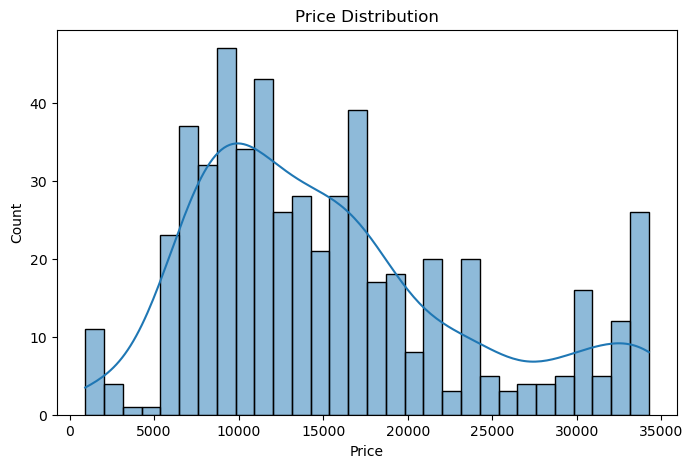

In [13]:
plt.figure(figsize=(8,5))

sns.histplot(df['Price'], kde=True, bins=30)

plt.title("Price Distribution")
plt.xlabel("Price")
plt.ylabel("Count")


plt.show()

## ***RAM Distribution***

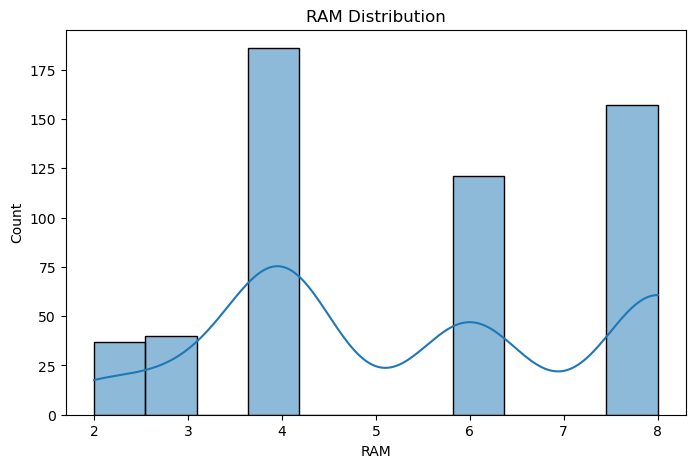

In [14]:
plt.figure(figsize=(8,5))

sns.histplot(df['RAM'], kde=True)

plt.title("RAM Distribution")
plt.xlabel("RAM")
plt.ylabel("Count")

plt.show()

## ***Memory Distribution***

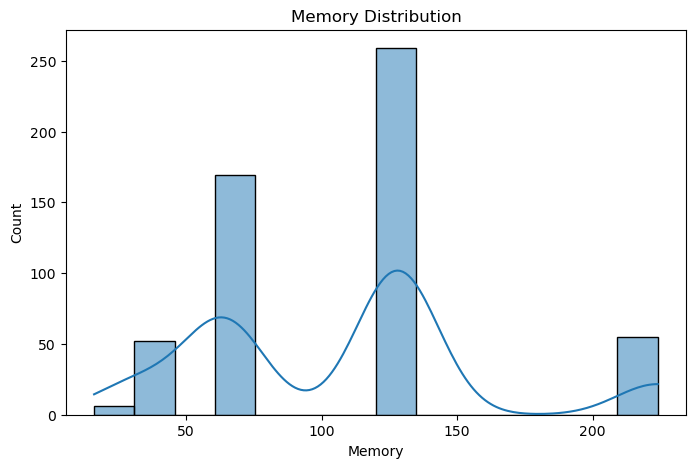

In [15]:
plt.figure(figsize=(8,5))

sns.histplot(df['Memory'], kde=True)

plt.title("Memory Distribution")
plt.xlabel("Memory")
plt.ylabel("Count")

plt.show()

***=> Created histograms using Seaborn (histplot) to visualize the distribution of Price, RAM, and Memory from the dataset.***  
***=> Added KDE curves (kde=True) to observe the overall trend of the data distribution.***  
***=> Set bins = 30 for the Price histogram to divide the price values into ranges.***  
***=> Added titles and axis labels for each chart to make the visualizations clear and understandable.***  
***=> Displayed the charts using Matplotlib (plt.show()).***  

## ***Memory vs Price Distribution***

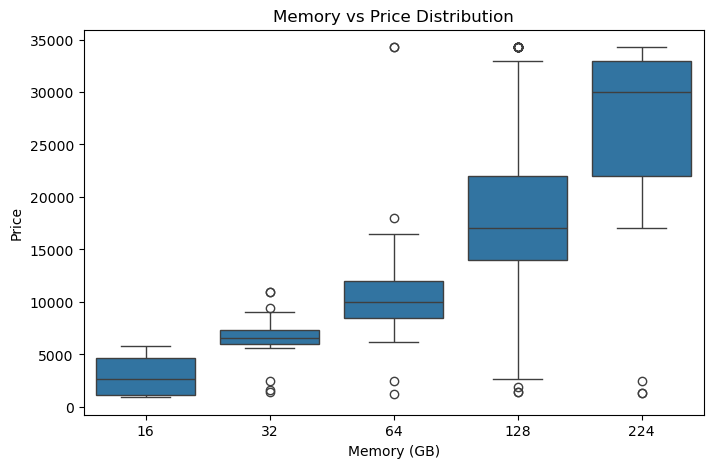

In [16]:
plt.figure(figsize=(8,5))

sns.boxplot(x='Memory', y='Price', data=df)

plt.title("Memory vs Price Distribution")
plt.xlabel("Memory (GB)")
plt.ylabel("Price")

plt.show()

## ***RAM vs Price Distribution***

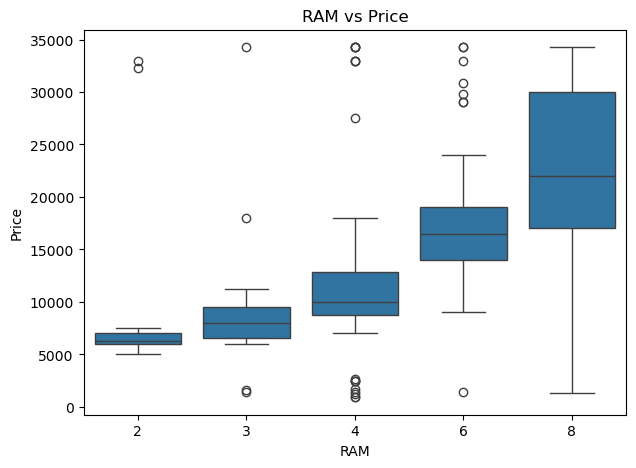

In [17]:
plt.figure(figsize=(7,5))

sns.boxplot(x='RAM', y='Price', data=df)

plt.title("RAM vs Price")

plt.show()

***=> Set the plot size using plt.figure().***  
***=> Created boxplot visualizations for RAM vs Price and Memory vs Price.***  
***=> Added titles and axis labels to the graphs.***  
***=> Analyzed the relationship between RAM, Memory, and Price.***  

### ***Convert camera columns from "13MP" → numeric***

In [18]:
df["Rear Camera"] = df["Rear Camera"].str.replace("MP", "").astype(int)
df["Front Camera"] = df["Front Camera"].str.replace("MP", "").astype(int)

***=> Converted camera resolution values from text format (e.g., "13MP") into numeric values for analysis.***  
***=> Removed the “MP” text from camera columns.***  
***=> Converted values into integers (numbers).***  

## ***Convert Categorical Variables → Labled Encoding***

In [19]:
df_encoded = df.copy()

cat_cols = df.select_dtypes(include='object').columns

for col in cat_cols:
    le = LabelEncoder()
    df_encoded[col] = le.fit_transform(df_encoded[col])

print("Original shape:", df.shape)
print("Encoded shape:", df_encoded.shape)


Original shape: (541, 11)
Encoded shape: (541, 11)


***=> Categorical features were converted into numerical form using Label Encoding.***  
***=> Each category was assigned a unique integer value.***  
***=> The dataset shape remained the same (541 rows and 11 columns), indicating that no data was lost during encoding.***  

## ***Correlation Analysis (Statistical Method)***

In [20]:
# Correlation with price
corr_matrix = df_encoded.corr()

price_corr = corr_matrix['Price'].sort_values(ascending=False)
price_corr

Price            1.000000
Memory           0.692721
Front Camera     0.651642
RAM              0.651490
Rear Camera      0.538359
Mobile Height    0.132029
Colour           0.040032
Battery_         0.030795
Model            0.006963
Processor_      -0.068051
AI Lens               NaN
Name: Price, dtype: float64

***=> Memory, RAM, and camera features show strong positive correlation with price.***  
***=> Devices with higher storage and RAM tend to have higher prices.***  
***=> Front Camera and Rear Camera also show moderate positive correlation with price.***  
***=> Mobile Height, Colour, Battery, and Model show very weak correlation with price.***  
***=> AI Lens has NaN correlation because it contains little or no variation.***  
***=> Memory, RAM, and Camera features appear to be the most influential factors for price prediction.***  

In [21]:
important_corr_features = price_corr[abs(price_corr) > 0.1]
important_corr_features

Price            1.000000
Memory           0.692721
Front Camera     0.651642
RAM              0.651490
Rear Camera      0.538359
Mobile Height    0.132029
Name: Price, dtype: float64

***=> Features with an absolute correlation greater than 0.1 were selected as important predictors for price.***

## ***Visualization — Correlation Heatmap***

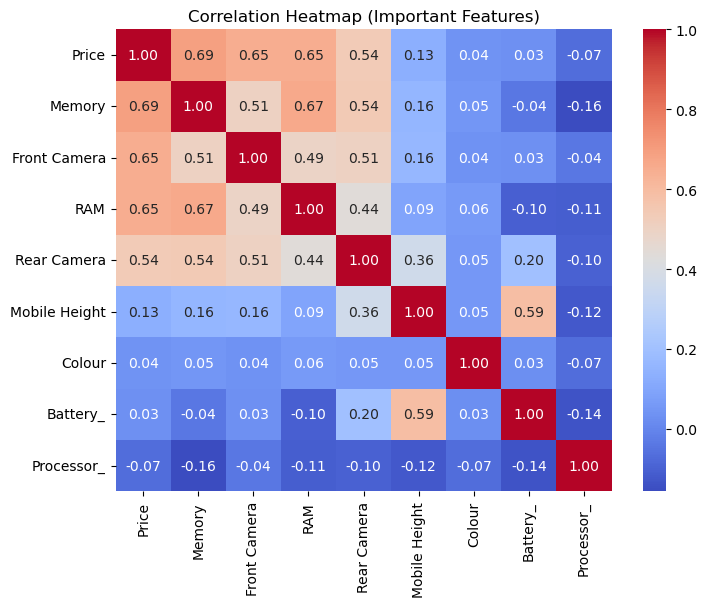

In [22]:
# Top features with price (abs corr > 0.01)
important_features = price_corr[abs(price_corr) > 0.01].index

plt.figure(figsize=(8,6))

sns.heatmap(
    df_encoded[important_features].corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap (Important Features)")
plt.show()

***=> Selected key features related to price and visualized their relationships using a correlation heatmap.***  
***=> Memory and RAM show strong positive correlation with price.***  
***=> Smartphones with higher storage and RAM tend to have higher prices.***  
***=> Front Camera and Rear Camera also show moderate positive correlation with price.***  
***=> Mobile Height, Colour, and Battery show weak relationships with price.***  
***=> Overall, Memory and RAM appear to be the most influential features for mobile price prediction.***  

## ***Feature Importance using Random Forest***

### ***Machine learning–based importance ranking.***

In [23]:
from sklearn.ensemble import RandomForestRegressor

X = df_encoded.drop('Price', axis=1)
y = df_encoded['Price']

model = RandomForestRegressor(random_state=42)
model.fit(X, y)

importance = pd.Series(model.feature_importances_, index=X.columns)
importance = importance.sort_values(ascending=False)

importance.head(15)

Front Camera     0.495839
Battery_         0.130588
Model            0.099056
Memory           0.088704
Rear Camera      0.052682
Processor_       0.050966
Mobile Height    0.032537
Colour           0.027614
RAM              0.022014
AI Lens          0.000000
dtype: float64

***📊Used a Random Forest model to find and rank the most important features affecting mobile price.***  

***CONCLUSION=>***  
***=> Front Camera appears as the most influential feature in the model.***  
***=> Battery and Model also show notable importance in predicting price.***  
***=> Memory and Rear Camera have moderate influence on mobile price.***  
***=> Processor and Mobile Height have smaller contributions.***  
***=> RAM and AI Lens show very low importance in the model.***  
***=> Overall, camera specifications and battery features play a stronger role in price prediction in this dataset.***  

### ***Create Importance DataFrame***

In [24]:
all_features = model.feature_names_in_
importances = model.feature_importances_

importance_df = pd.DataFrame({
    "Feature": all_features,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

importance_df.head(10)

,Feature,Importance
6,Front Camera,0.495839
4,Battery_,0.130588
0,Model,0.099056
2,Memory,0.088704
5,Rear Camera,0.052682
9,Processor_,0.050966
8,Mobile Height,0.032537
1,Colour,0.027614
3,RAM,0.022014
7,AI Lens,0.000000


***📊 Created a sorted DataFrame showing feature importance scores from the trained model.***  

***Conclusion=>***  
***=> Listed all input features used by the model.***  
***=> Retrieved importance scores for each feature.***  
***=> Sorted features from most to least important.***  
***=> Identified the top factors influencing mobile price (e.g., Front Camera, Battery, Model).***  
***=> Helps interpret which features impact predictions the most.***  

### ***Visualization of Important Features***

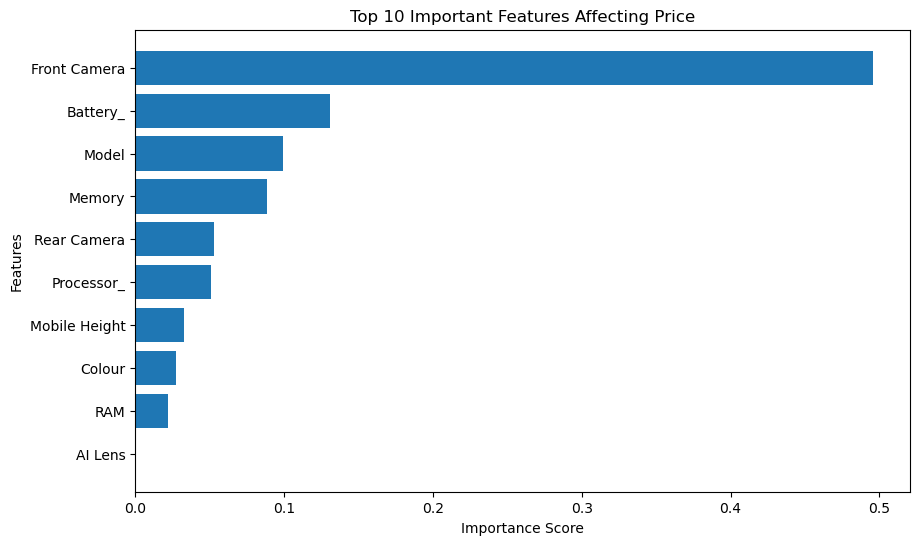

In [25]:
importance_df_clean = importance_df[
    ~importance_df["Feature"].str.contains("Unnamed", case=False)
]

plt.figure(figsize=(10,6))

plt.barh(
    importance_df_clean["Feature"][:10],
    importance_df_clean["Importance"][:10]
)

plt.xlabel("Importance Score")
plt.ylabel("Features")
plt.title("Top 10 Important Features Affecting Price")

plt.gca().invert_yaxis()

plt.show()

***📊 Visualized the top 10 most important features affecting mobile price using a horizontal bar chart.***  

***Conclusion=>.***  
***=> Front Camera appears as the most influential feature affecting mobile price.***    
***=> Battery and Model also show significant importance in the prediction.***    
***=> Memory and Rear Camera have moderate influence on price.***    
***=> Processor and Mobile Height contribute smaller effects.***    
***=> RAM and AI Lens have very low importance in the model.***    
***=> Overall, camera specifications and battery capacity play a stronger role in price prediction in this dataset.***    

## ***Model Building — Price Prediction***

### ***Feature and target Seperation***

In [26]:
X = df.drop("Price", axis=1)   # Features
y = df["Price"]                # Target (Price)
categorical_cols = ["Model", "Colour", "Processor_"]

numerical_cols = [
    "Memory", "RAM", "Battery_", 
    "Rear Camera", "Front Camera",
    "AI Lens", "Mobile Height"
]
print(categorical_cols)
print(numerical_cols)

['Model', 'Colour', 'Processor_']
['Memory', 'RAM', 'Battery_', 'Rear Camera', 'Front Camera', 'AI Lens', 'Mobile Height']


***📊 Separated the dataset into input features and target variable (Price), and identified categorical and numerical columns.*** 

***Conclusion=>***  
***=> Price was selected as the target variable.***  
***=> Remaining columns were used as input features.***  
***=> Categorical features (e.g., Model, Colour, Processor) were identified.***  
***=> Numerical features (e.g., RAM, Memory, Battery) were listed separately.***  
***=> Prepared the data for preprocessing and model training.***  

### ***Preprocessing (Encoding Categorical Data)***

In [27]:
numeric_cols = X.select_dtypes(include=['int64','float64']).columns
categorical_cols = X.select_dtypes(include=['object']).columns

preprocessor = ColumnTransformer([
    ("num", SimpleImputer(strategy="median"), numeric_cols),

    ("cat", Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(handle_unknown="ignore"))
    ]), categorical_cols)
])

***📊Preprocessed the data by handling missing values and encoding categorical features for machine learning.***  

***Conclusion=>***  
***=> Numerical missing values were filled using the median***  
***=> Categorical missing values were filled using the most frequent value***  
***=> Categorical features were converted into numeric form using One-Hot Encoding***  
***=> Unknown categories were safely ignored during transformation***  
***=> Data is now clean and ready for model training***  

### ***Train-Test Split***

In [28]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

***Split the dataset into training and testing sets to evaluate the model’s performance.***  
***=> 80% data is used for training the model.***  
***=> 20% data is reserved for testing.***  

## ***Model Training***

### ***Linear Regression***

In [29]:
lr_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LinearRegression())
])

lr_model.fit(X_train, y_train)
y_pred_lr = lr_model.predict(X_test)

###Evaluation
print("Linear Regression Results")
print("MAE:", mean_absolute_error(y_test, y_pred_lr))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_lr)))
print("R2 Score:", r2_score(y_test, y_pred_lr))
lr_r2=r2_score(y_test,lr_model.predict(X_test))

Linear Regression Results
MAE: 1573.893676879888
RMSE: 2775.3261423143254
R2 Score: 0.8680347140870057


***📊 Built and evaluated a Linear Regression model to predict mobile prices.***  

***Conclusion=>***  
***=> Model achieved good accuracy (R² ≈ 0.87).***  
***=> The Mean Absolute Error (MAE) indicates that the average prediction error is around 1573.***  
***=> The RMSE value suggests that some predictions have larger deviations, but overall the model performs well.***  
***=> Overall, Linear Regression provides a good baseline model for predicting mobile prices.***  

### ***Decision Tree***

In [30]:
dt_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", DecisionTreeRegressor(
        max_depth=None,
        random_state=42
    ))
])

# Train
dt_model.fit(X_train, y_train)
# Predict
y_pred_dt = dt_model.predict(X_test)
# Evaluation
print("Decision Tree Results")

print("MAE:", mean_absolute_error(y_test, y_pred_dt))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_dt)))
print("R2 Score:", r2_score(y_test, y_pred_dt))

Decision Tree Results
MAE: 874.7798165137615
RMSE: 2734.740923274304
R2 Score: 0.8718661046837012


***📊 Built and evaluated a Decision Tree Regression model to predict mobile prices.***  

.***Conclusion=>.***  
***=> Model achieved good accuracy (R² ≈ 0.87).***  
***=> Prediction error (MAE) is relatively low.***  
***=> RMSE indicates that some predictions have larger deviations.***  
***=> Decision Tree performs slightly better than Linear Regression for this dataset.***  
***=> Decision Tree models can capture nonlinear relationships between features and price.***  

### ***Random Forest***

In [31]:
rf_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(
        n_estimators=100,
        random_state=42
    ))
])

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

###Evaluation
print("Random Forest Results")
print("MAE:", mean_absolute_error(y_test, y_pred_rf))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_rf)))
print("R2 Score:", r2_score(y_test, y_pred_rf))
rf_r2 = r2_score(y_test, y_pred_rf)

Random Forest Results
MAE: 1406.0030733944952
RMSE: 2994.7963675852934
R2 Score: 0.8463380835594956


***📊 Built and evaluated a Random Forest Regression model to predict mobile prices.***  

***Conclusion=>***  
***=> The Random Forest model achieved good performance with an R² score of approximately 0.85.***  
***=> The Mean Absolute Error (MAE) indicates moderate prediction error.***  
***=> The RMSE value suggests that some predictions have larger deviations.***  
***=> Compared to the other models, Random Forest performs slightly lower for this dataset.***  
***=> Random Forest models combine multiple decision trees and are effective at capturing complex patterns in data.***  

### ***Compare All Models***

In [32]:
lr_mae = mean_absolute_error(y_test, y_pred_lr)
lr_rmse = np.sqrt(mean_squared_error(y_test, y_pred_lr))
lr_r2 = r2_score(y_test, y_pred_lr)

dt_mae = mean_absolute_error(y_test, y_pred_dt)
dt_rmse = np.sqrt(mean_squared_error(y_test, y_pred_dt))
dt_r2 = r2_score(y_test, y_pred_dt)

rf_mae = mean_absolute_error(y_test, y_pred_rf)
rf_rmse = np.sqrt(mean_squared_error(y_test, y_pred_rf))
rf_r2 = r2_score(y_test, y_pred_rf)

results = pd.DataFrame({
    "Model": ["Linear Regression", "Decision Tree", "Random Forest"],

    "MAE": [lr_mae, dt_mae, rf_mae],

    "RMSE": [lr_rmse, dt_rmse, rf_rmse],

    "R2 Score": [lr_r2, dt_r2, rf_r2]
})

results

,Model,MAE,RMSE,R2 Score
0,Linear Regression,1573.893677,2775.326142,0.868035
1,Decision Tree,874.779817,2734.740923,0.871866
2,Random Forest,1406.003073,2994.796368,0.846338


***📊 Compared the performance of Linear Regression, Decision Tree, and Random Forest models using evaluation metrics.***  

***Conclusion=>***  
***=> Decision Tree achieved the highest R² score and the lowest MAE and RMSE, indicating the best predictive performance.***  
***=> Linear Regression also performed well and served as a strong baseline model.***  
***=> Random Forest showed slightly lower performance for this dataset.***  
***=> Overall, the Decision Tree model was selected as the best model for predicting mobile prices.***  

### ***Extract Feature Names***

In [33]:
# Get feature names from preprocessor
cat_features = preprocessor.named_transformers_["cat"].get_feature_names_out(categorical_cols)

all_features = list(cat_features) + numerical_cols

***📊 Extracted the final feature names after encoding and combined them with numerical features.***  

***=>Conclusion=>***  
***=>Retrieved new feature names created by One-Hot Encoding.***  
***=>Included original numerical feature names.***  
***=>Combined all features into a single list.***  
***=>Prepared feature names for interpretation or visualization.***  
***=>Helps understand model input after preprocessing.***  


### ***Predicted Mobile Prices***

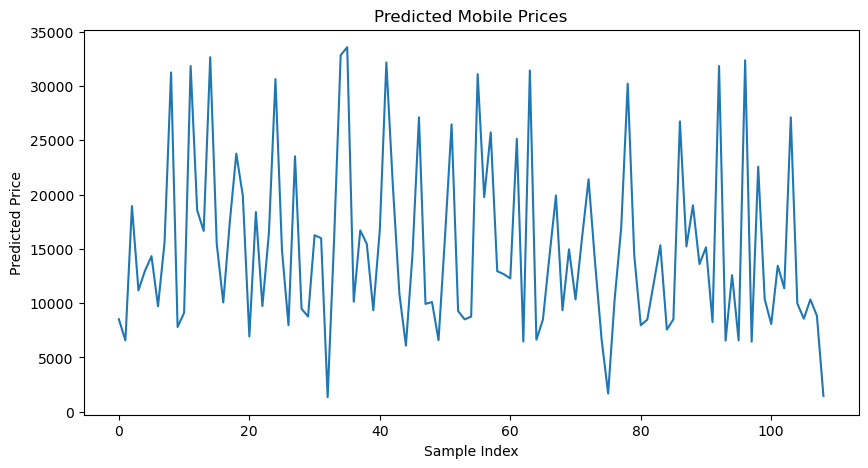

In [34]:
plt.figure(figsize=(10,5))

plt.plot(y_pred_rf)

plt.xlabel("Sample Index")
plt.ylabel("Predicted Price")
plt.title("Predicted Mobile Prices")

plt.show()

***📊  Visualized the predicted mobile prices for test samples using a line plot.***  

***Conclusion=>***  
***=>Shows how predicted prices vary across different samples.***  
***=>Model predicts a wide range of prices (low to high).***  
***=>Fluctuations indicate differences in phone specifications.***  
***=>No constant pattern, reflecting diverse data***  
***=>Helps visually inspect prediction distribution***  

## ***Actual vs Predicted Price***

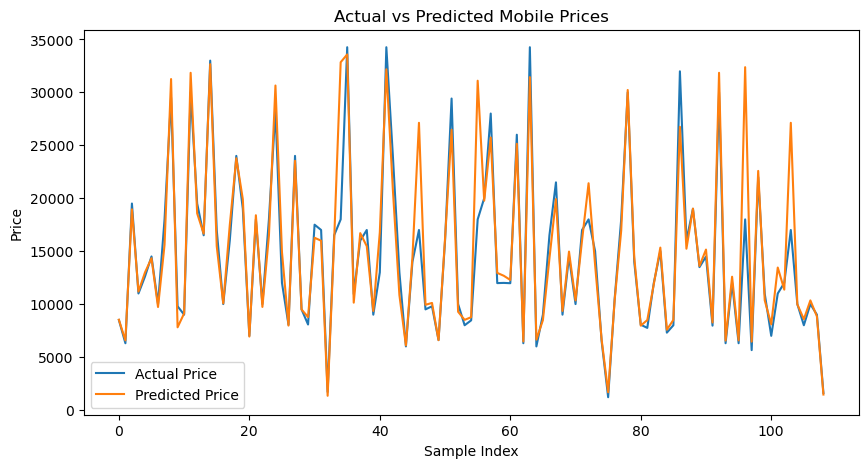

In [35]:
plt.figure(figsize=(10,5))

plt.plot(y_test.values, label="Actual Price")
plt.plot(y_pred_rf, label="Predicted Price")

plt.xlabel("Sample Index")
plt.ylabel("Price")
plt.title("Actual vs Predicted Mobile Prices")
plt.legend()

plt.show()

***📊 Compared actual mobile prices with predicted prices using a line plot.***  

***Conclusion=>***  
***=>Predicted prices closely follow the actual prices.***  
***=>Model captures overall price trends well.***  
***=>Some deviations exist at certain samples.***  
***=>Indicates good but not perfect prediction accuracy.***  
***=>Overall, the model performs reliably on test data.***  

## ***Error Distribution of Price***

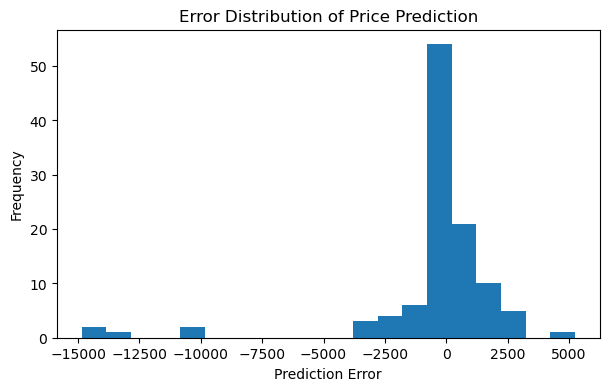

In [36]:
errors = y_test - y_pred_rf

plt.figure(figsize=(7,4))
plt.hist(errors, bins=20)
plt.xlabel("Prediction Error")
plt.ylabel("Frequency")
plt.title("Error Distribution of Price Prediction")

plt.show()

***📊 Visualized the distribution of prediction errors using a histogram.***  

***=>Conclusion=>***  
***=>Most errors are concentrated around zero.***  
***=>Model predictions are generally close to actual prices.***  
***=>Few large errors (outliers) exist.***  
***=>Error distribution appears roughly centered.***  
***=>Indicates overall good prediction accuracy.***  

### ***📊  Conclusion of this Project=>***  

***1=> This project analyzed various smartphone specifications to understand how different features influence mobile phone prices. Exploratory Data Analysis helped identify patterns and relationships between hardware specifications and price.***  

***2=> Correlation analysis showed that memory, RAM, and camera specifications have noticeable relationships with mobile price. Devices with higher memory and better camera capabilities generally tend to have higher prices.***  

***3=> Feature importance analysis using Random Forest revealed that camera specifications, battery capacity, memory, and model type play important roles in determining smartphone prices.***  

***4=> Three machine learning models were trained and evaluated:***  

 ***=> Linear Regression***  

 ***=> Decision Tree Regressor***  

 ***=> Random Forest Regressor***  

***5=> Based on evaluation metrics (MAE, RMSE, and R² Score), the Decision Tree model achieved the best performance with the highest R² score and lowest prediction error among the tested models.***  

***6=> Visualization of actual vs predicted prices showed that the model predictions closely follow the real price trends, indicating that the model successfully captures the relationship between phone specifications and price.***  

***7=> Error distribution analysis showed that most prediction errors are concentrated near zero, suggesting that the model generally makes accurate predictions with only a few larger deviations.***  

 


### ***Recommendation=>***  

***Based on the analysis and model results, smartphone manufacturers should focus on improving camera quality, battery capacity, RAM, and 
storage configurations when targeting higher price segments. These features have shown a strong influence on mobile phone pricing and customer
value perception.***    